<a href="https://colab.research.google.com/github/MaCuur/AI_EGs/blob/main/lstm_timeseries_univariado_multistep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#*FORECASTING* CON REDES LSTM - PARTE 3: MODELO UNIVARIADO - MULTISTEP

## Contenido

1. [Introducción](#scrollTo=wHQ1yXwrk6CN)
2. [El set de datos](#scrollTo=QDm0J6L-7rGI&line=1&uniqifier=1)
3. [El problema a resolver](#scrollTo=CBJV_YRvj5CZ&line=1&uniqifier=1)
4. [Lectura del set de datos](#scrollTo=Es6L4nEckb3S&line=1&uniqifier=1)
5. [Pre-procesamiento](#scrollTo=vd5lyqNrlfFg)
6. [Creación y entrenamiento del modelo](#scrollTo=016D9eVw3Beb)
7. [Desempeño del modelo](#scrollTo=ZkI9vr5S69i_)
8. [Predicciones con el modelo entrenado](#scrollTo=fvqk4f8L3aXE&line=1&uniqifier=1)
9. [Conclusiones y sugerencias](#scrollTo=0AFY2trj_KLo&line=1&uniqifier=1)

## 1. Introducción

En los tres primeros videos de esta serie hemos visto un panorama general sobre los tipos de predicción y el pre-procesamiento que debemos hacer sobre los datos, así como la implementación del modelo de predicción más sencillo de todos: la Red LSTM univariada-unistep.

En este video veremos cómo implementar una Red LSTM que tome a la entrada una sola variable y que a la salida prediga múltiples instantes de tiempo. Así que veremos cómo implementar un modelo de predicción univariado y multistep.

Tomaremos como base la mayor parte del código que implementamos en el video anterior, aunque haremos algunas modificaciones al pre-procesamiento de los datos y a la Red LSTM para poder generar predicciones multi-step.

##2. El set de datos

Recordemos que estamos usando el  [weather dataset](https://www.bgc-jena.mpg.de/wetter/weather_data.html), un set de datos que contiene el registro histórico de 14 diferentes variables climáticas en el período entre 2009 y 2015.

En el segundo video de la serie realizamos el análisis exploratorio del dataset y realizamos este pre-procesamiento:

1. Hicimos el manejo de datos faltantes
2. Verificamos que el dataset no tuviese valores extremos
3. Re-interpolamos el dataset para garantizar una periodicidad de 1 hora

Este será el set de datos que usaremos en este tutorial.

##3. El problema a resolver

Crear y entrenar una Red LSTM usando el enfoque univariado + multi-step:

![](https://drive.google.com/uc?export=view&id=15f7JrWSqoanfqMvselC67AtNWTrdiwPy)

De nuevo la variable de entrada y de salida al modelo seguirá siendo una sóla: la temperatura.

En lo que resta de este tutorial haremos uso de buena parte de la implementación realizada en el video anterior (modelo univariado + uni-step) y nos enfocaremos sólo en algunas diferencias:

- **Pre-procesamiento**: modificaremos la creación del dataset supervisado, para que en lugar de 1 instante de tiempo a futuro el dataset contenga 4 horas de temperatura a futuro
- **Red LSTM**: seguirá aceptando el mismo número de horas consecutivas a la entrada (24 horas) pero generará 4 horas de predicción a la salida.
- **Desempeño del modelo**: como ahora generará 4 instantes de tiempo consecutivos y no sólo 1 durante la predicción, veremos una forma de analizar el desempeño del modelo en este caso.

##4. Lectura del set de datos

Recordemos que usaremos el dataset implementado en el [segundo video de la serie](https://youtu.be/R8MEPGn9sFI), sobre el cual ya hemos hecho un pre-procesamiento previo:

In [3]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Montar Google Drive
#drive.mount('/gdrive')

# Leer set de datos
#ruta = '/gdrive/MyDrive/02-CODIFICANDOBITS.COM/05-YouTube/02-Videos/2023-05-05-LSTMSeriesTiempo-Univariate-Multistep/release/data/'
df = pd.read_csv('weather_dataset_preprocesado.csv')
df

,datetime,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.40,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
1,2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.20,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2,2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.50,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
3,2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.60,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
4,2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.20,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50219,2014-09-24 12:00:00,987.01,13.69,287.92,6.29,60.85,15.69,9.55,6.14,6.04,9.67,1194.28,2.92,4.00,174.1
50220,2014-09-24 13:00:00,986.55,14.19,288.47,6.80,61.01,16.21,9.89,6.32,6.26,10.02,1191.48,1.57,2.48,173.0
50221,2014-09-24 14:00:00,986.21,14.99,289.30,6.70,57.54,17.07,9.82,7.25,6.22,9.96,1187.80,2.79,4.75,202.5
50222,2014-09-24 15:00:00,984.76,15.20,289.63,6.96,57.79,17.30,10.00,7.30,6.34,10.15,1185.10,2.86,4.32,172.0


##5. Pre-procesamiento

Implica:

1. Partición en train/val/test (80%, 10%, 10%).
2. Generación del dataset supervisado: entrada y salida del modelo
3. Escalamiento

En las fases (1) y (3) usaremos la misma implementación del tutorial anterior, así que nos enfocaremos principalmente en la fase (2) (generación del dataset supervisado).

### 5.1. Partición del set en entrenamiento, validación y prueba

A diferencia de otros modelos de Machine Learning, en el caso de series de tiempo **se debe garantizar que se generan las particiones sin mezclar aleatoriamente los datos**.

Recordemos además que:
- El set de entrenamiento (*train*) se usará para encontrar los parámetros del modelo
- El set de validación (*val*) para verificar que no haya *under/over-fitting* del modelo y para ajustar sus hiperparámetros
- El set de prueba (*test*) para poner a prueba el mejor modelo encontrado durante el entrenamiento/validación

In [4]:
# Función para generar las particiones preservando las características
# de la serie de tiempo

def train_val_test_split(serie, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    # Definir número de datos en cada subserie
    N = serie.shape[0]
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = N - Ntrain - Nval # Número de datos de prueba

    # Realizar partición
    train = serie[0:Ntrain]
    val = serie[Ntrain:Ntrain+Nval]
    test = serie[Ntrain+Nval:]

    return train, val, test

# Prueba de la función
tr, vl, ts = train_val_test_split(df['T (degC)'])

print(f'Tamaño set de entrenamiento: {tr.shape}')
print(f'Tamaño set de validación: {vl.shape}')
print(f'Tamaño set de prueba: {ts.shape}')

Tamaño set de entrenamiento: (40179,)
Tamaño set de validación: (5022,)
Tamaño set de prueba: (5023,)


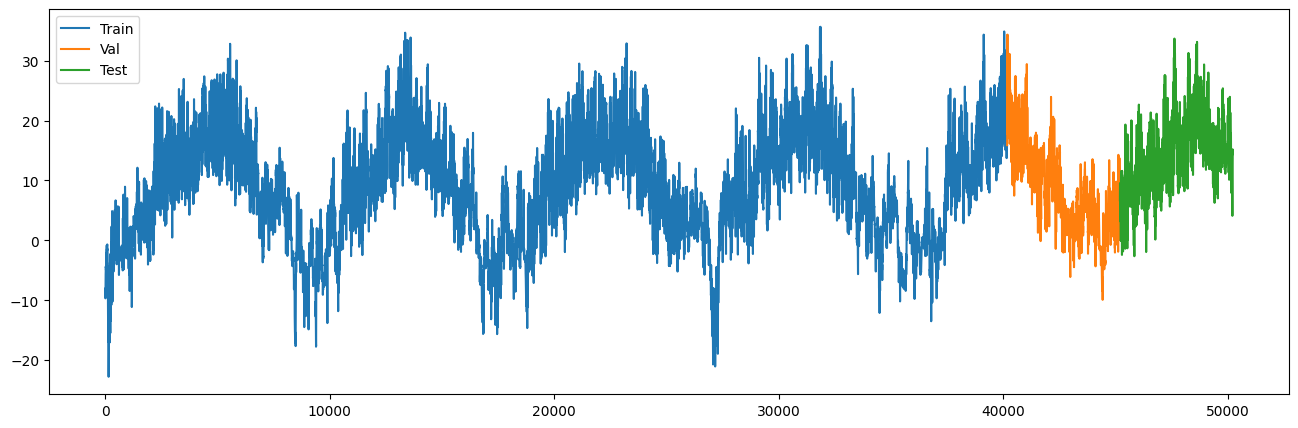

In [5]:
# Dibujemos los subsets
fig, ax = plt.subplots(figsize = (16,5))
ax.plot(tr, label='Train')
ax.plot(vl, label='Val')
ax.plot(ts, label='Test')
plt.legend();

Observemos que por ser un modelo univariado sólo estamos preservando la variable temperatura (y que incluso hemos eliminado la información de fecha y hora de cada registro).

###5.2 Generación del dataset supervisado (entrada y salida del modelo)

Debemos ajustar nuestro set de datos de acuerdo a lo especificado en la [documentación de las Redes LSTM en TensorFlow/Keras](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM):

![](https://drive.google.com/uc?export=view&id=167iC5It71vi9QrsjFyEHsU3mGyXbCEPe)

Así que en este caso cada dato de entrenamiento será:

- Un arreglo de 24 (horas) x 1 (feature) correspondiente a la entrada
- Un arreglo de 4 (hora) x 1 (feature) correspondiente a la hora 25 (a predecir):

![](https://drive.google.com/uc?export=view&id=16B13bFGkdMkO2UudYBowp6AAA8szblm-)

La única diferencia con relación al set de datos supervisado usado en el enfoque univariado + uni-step es que a la salida vamos a predecir 4 horas y no sólo 1.

Este parámetro de salida (`OUTPUT_LENGTH = 4`) se convierte en un hiperparámetro que terminará afectando el desempeño de la Red LSTM al momento de hacer las predicciones.

Y usaremos la misma función creada en el tutorial anterior:

In [6]:
def crear_dataset_supervisado(array, input_length, output_length):
    '''Permite crear un dataset con las entradas (X) y salidas (Y)
    requeridas por la Red LSTM.

    Parámetros:
    - array: arreglo numpy de tamaño N x features (N: cantidad de datos,
      f: cantidad de features)
    - input_length: instantes de tiempo consecutivos de la(s) serie(s) de tiempo
      usados para alimentar el modelo
    - output_length: instantes de tiempo a pronosticar (salida del modelo)
    '''

    # Inicialización
    X, Y = [], []    # Listados que contendrán los datos de entrada y salida del modelo
    shape = array.shape
    if len(shape)==1: # Si tenemos sólo una serie (univariado)
        fils, cols = array.shape[0], 1
        array = array.reshape(fils,cols)
    else: # Multivariado
        fils, cols = array.shape

    # Generar los arreglos
    for i in range(fils-input_length-output_length):
        X.append(array[i:i+INPUT_LENGTH,0:cols])
        Y.append(array[i+input_length:i+input_length+output_length,-1].reshape(output_length,1))

    # Convertir listas a arreglos de NumPy
    X = np.array(X)
    Y = np.array(Y)

    return X, Y

In [7]:
# Crear los datasets de entrenamiento, prueba y validación y verificar sus tamaños
INPUT_LENGTH = 24    # Posteriormente afinaremos este hiperparámetro
OUTPUT_LENGTH = 4    # Modelo uni-step: ***EL ÚNICO CAMBIO QUE DEBEMOS HACER***

x_tr, y_tr = crear_dataset_supervisado(tr.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_vl, y_vl = crear_dataset_supervisado(vl.values, INPUT_LENGTH, OUTPUT_LENGTH)
x_ts, y_ts = crear_dataset_supervisado(ts.values, INPUT_LENGTH, OUTPUT_LENGTH)

# Imprimir información en pantalla
print('Tamaños entrada (BATCHES x INPUT_LENGTH x FEATURES) y de salida (BATCHES x OUTPUT_LENGTH x FEATURES)')
print(f'Set de entrenamiento - x_tr: {x_tr.shape}, y_tr: {y_tr.shape}')
print(f'Set de validación - x_vl: {x_vl.shape}, y_vl: {y_vl.shape}')
print(f'Set de prueba - x_ts: {x_ts.shape}, y_ts: {y_ts.shape}')

Tamaños entrada (BATCHES x INPUT_LENGTH x FEATURES) y de salida (BATCHES x OUTPUT_LENGTH x FEATURES)
Set de entrenamiento - x_tr: (40151, 24, 1), y_tr: (40151, 4, 1)
Set de validación - x_vl: (4994, 24, 1), y_vl: (4994, 4, 1)
Set de prueba - x_ts: (4995, 24, 1), y_ts: (4995, 4, 1)


###5.3 Escalamiento

Es requerido para garantizar que todas las características se encuentran en el mismo rango de valores, lo que facilita el entrenamiento del modelo y las predicciones:

In [8]:
from sklearn.preprocessing import MinMaxScaler

def escalar_dataset(data_input):
    '''Escala el dataset en el rango de -1 a 1.

    Entradas:
    data_input: diccionario con los dataset de entrada y salida del modelo
    (data_input = {'x_tr':x_tr, 'y_tr':y_tr, 'x_vl':x_vl, 'y_vl':y_vl,
                    'y_ts':y_ts})

    Retorna:
    - data_scaled: diccionario con los datasets de entrada y salida escalados
      (tiene la misma estructura del diccionario de entrada)
    - scaler: el escalador usado (requerido para las predicciones)
    '''

    NFEATS = data_input['x_tr'].shape[2]

    # Generar listado con "scalers" (en este caso, por ser sólo 1 característica
    # se tendrá sólo 1 escalador)
    scalers = [MinMaxScaler(feature_range=(-1,1)) for i in range(NFEATS)]

    # Arreglos que contendrán los datasets escalados
    x_tr_s = np.zeros(data_input['x_tr'].shape)
    x_vl_s = np.zeros(data_input['x_vl'].shape)
    x_ts_s = np.zeros(data_input['x_ts'].shape)
    y_tr_s = np.zeros(data_input['y_tr'].shape)
    y_vl_s = np.zeros(data_input['y_vl'].shape)
    y_ts_s = np.zeros(data_input['y_ts'].shape)

    # Escalamiento: se usarán los min/max del set de entrenamiento para
    # escalar la totalidad de los datasets

    # Escalamiento Xs
    for i in range(NFEATS):
        x_tr_s[:,:,i] = scalers[i].fit_transform(x_tr[:,:,i])
        x_vl_s[:,:,i] = scalers[i].transform(x_vl[:,:,i])
        x_ts_s[:,:,i] = scalers[i].transform(x_ts[:,:,i])

    # Escalamiento Ys
    y_tr_s[:,:,0] = scalers[-1].fit_transform(y_tr[:,:,0])
    y_vl_s[:,:,0] = scalers[-1].transform(y_vl[:,:,0])
    y_ts_s[:,:,0] = scalers[-1].transform(y_ts[:,:,0])

    # Conformar diccionario de salida
    data_scaled = {
        'x_tr_s': x_tr_s, 'y_tr_s': y_tr_s,
        'x_vl_s': x_vl_s, 'y_vl_s': y_vl_s,
        'x_ts_s': x_ts_s, 'y_ts_s': y_ts_s,
    }

    return data_scaled, scalers[0]

In [9]:
# Escalamiento del dataset con la función anterior

# Crear diccionario de entrada
data_in = {
    'x_tr': x_tr, 'y_tr': y_tr,
    'x_vl': x_vl, 'y_vl': y_vl,
    'x_ts': x_ts, 'y_ts': y_ts,
}

# Y escalar
data_s, scaler = escalar_dataset(data_in)

# Extraer subsets escalados
x_tr_s, y_tr_s = data_s['x_tr_s'], data_s['y_tr_s']
x_vl_s, y_vl_s = data_s['x_vl_s'], data_s['y_vl_s']
x_ts_s, y_ts_s = data_s['x_ts_s'], data_s['y_ts_s']

# Verificación
print(f'Min x_tr/x_vl/x_ts sin escalamiento: {x_tr.min()}/{x_vl.min()}/{x_ts.min()}')
print(f'Min x_tr/x_vl/x_ts con escalamiento: {x_tr_s.min()}/{x_vl_s.min()}/{x_ts_s.min()}')

print(f'\nMin y_tr/y_vl/y_ts sin escalamiento: {y_tr.min()}/{y_vl.min()}/{y_ts.min()}')
print(f'Min y_tr/y_vl/y_ts con escalamiento: {y_tr_s.min()}/{y_vl_s.min()}/{y_ts_s.min()}')

print(f'\nMax x_tr/x_vl/x_ts sin escalamiento: {x_tr.max()}/{x_vl.max()}/{x_ts.max()}')
print(f'Max x_tr/x_vl/x_ts con escalamiento: {x_tr_s.max()}/{x_vl_s.max()}/{x_ts_s.max()}')

print(f'\nMax y_tr/y_vl/y_ts sin escalamiento: {y_tr.max()}/{y_vl.max()}/{y_ts.max()}')
print(f'Max y_tr/y_vl/y_ts con escalamiento: {y_tr_s.max()}/{y_vl_s.max()}/{y_ts_s.max()}')


Min x_tr/x_vl/x_ts sin escalamiento: -22.76/-9.92/-2.64
Min x_tr/x_vl/x_ts con escalamiento: -1.0/-0.5603492552645094/-0.31107687039890414

Min y_tr/y_vl/y_ts sin escalamiento: -22.76/-9.92/-2.64
Min y_tr/y_vl/y_ts con escalamiento: -1.0/-0.5603492552645094/-0.31107687039890414

Max x_tr/x_vl/x_ts sin escalamiento: 35.65/34.34/33.68
Max x_tr/x_vl/x_ts con escalamiento: 1.0000000000000002/0.9551446670090742/0.932545796952577

Max y_tr/y_vl/y_ts sin escalamiento: 35.65/31.33/33.68
Max y_tr/y_vl/y_ts con escalamiento: 1.0000000000000002/0.8520801232665642/0.932545796952577


##6. Creación y entrenamiento del modelo

- Entradas: arreglos *x* (batches x input-length  x features = batches x 24 x 1)
- Salidas: arreglos *y* (batches x output-length x features = batches x 4 x 1)

Usaremos la raíz cuadrada del error cuadrático medio (o RMSE por sus siglas en Inglés: *root mean square error*) como pérdida para entrenar el modelo:

$RMSE = \sqrt{\frac{\sum_i (y_i-\hat{y_i})^2}{N}}$

donde:
- $y$: temperatura real
- $\hat{y}$: temperatura predicha
- $N$: cantidad de predicciones

In [10]:
# Creación del modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import RMSprop
import tensorflow as tf

# Ajustar parámetros para reproducibilidad del entrenamiento
tf.random.set_seed(123)
tf.config.experimental.enable_op_determinism()

# El modelo
N_UNITS = 128 # Tamaño del estado oculto (h) y de la celdad de memoria (c)
INPUT_SHAPE = (x_tr_s.shape[1], x_tr_s.shape[2]) # 24 (horas) x 1 (feature)

modelo = Sequential()
modelo.add(LSTM(N_UNITS, input_shape=INPUT_SHAPE))

# Y lo único que cambia con respecto al modelo univariado + uni-step es
# el tamaño deldato de salida
modelo.add(Dense(OUTPUT_LENGTH, activation='linear')) # activation = 'linear' pues queremos pronosticar (regresión)

# Pérdida: se usará el RMSE (root mean squared error) para el entrenamiento
# pues permite tener errores en las mismas unidades de la temperatura
def root_mean_squared_error(y_true, y_pred):
    rmse = tf.math.sqrt(tf.math.reduce_mean(tf.square(y_pred-y_true)))
    return rmse

# Compilación
optimizador = RMSprop(learning_rate=5e-5)
modelo.compile(
    optimizer = optimizador,
    loss = root_mean_squared_error,
)

# Entrenamiento (aproximadamente 1 min usando GPU)
EPOCHS = 80 # Hiperparámetro
BATCH_SIZE = 256 # Hiperparámetro
historia = modelo.fit(
    x = x_tr_s,
    y = y_tr_s,
    batch_size = BATCH_SIZE,
    epochs = EPOCHS,
    validation_data = (x_vl_s, y_vl_s),
    verbose=2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/80
157/157 - 3s - 19ms/step - loss: 0.2370 - val_loss: 0.1138
Epoch 2/80
157/157 - 1s - 5ms/step - loss: 0.1251 - val_loss: 0.1020
Epoch 3/80
157/157 - 1s - 5ms/step - loss: 0.1179 - val_loss: 0.0988
Epoch 4/80
157/157 - 1s - 5ms/step - loss: 0.1129 - val_loss: 0.0958
Epoch 5/80
157/157 - 1s - 5ms/step - loss: 0.1083 - val_loss: 0.0928
Epoch 6/80
157/157 - 1s - 5ms/step - loss: 0.1039 - val_loss: 0.0898
Epoch 7/80
157/157 - 1s - 6ms/step - loss: 0.0997 - val_loss: 0.0869
Epoch 8/80
157/157 - 1s - 5ms/step - loss: 0.0957 - val_loss: 0.0842
Epoch 9/80
157/157 - 1s - 5ms/step - loss: 0.0923 - val_loss: 0.0818
Epoch 10/80
157/157 - 1s - 7ms/step - loss: 0.0894 - val_loss: 0.0797
Epoch 11/80
157/157 - 1s - 8ms/step - loss: 0.0872 - val_loss: 0.0781
Epoch 12/80
157/157 - 1s - 8ms/step - loss: 0.0856 - val_loss: 0.0767
Epoch 13/80
157/157 - 1s - 5ms/step - loss: 0.0842 - val_loss: 0.0755
Epoch 14/80
157/157 - 1s - 5ms/step - loss: 0.0830 - val_loss: 0.0743
Epoch 15/80
157/157 - 1s - 5

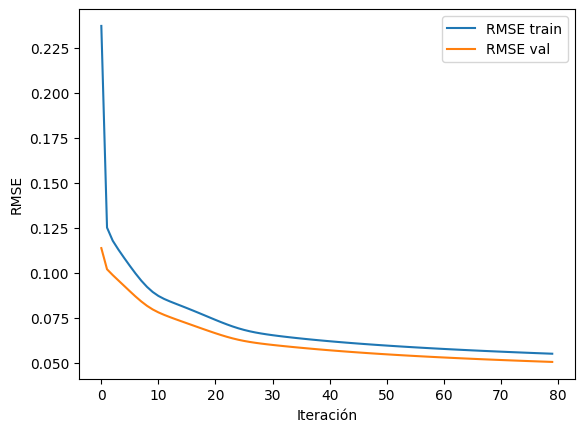

In [11]:
 # Graficar curvas de entrenamiento y validación
 # para verificar que no existe overfitting
plt.plot(historia.history['loss'],label='RMSE train')
plt.plot(historia.history['val_loss'],label='RMSE val')
plt.xlabel('Iteración')
plt.ylabel('RMSE')
plt.legend();

**Observaciones y sugerencias:**

- El modelo no tiene *overfitting* (algo similar a lo que ocurrió con el modelo univariado + uni-step)
- El modelo podría ser entrenado con un número mayor de iteraciones (hiperparámetro).
- Al igual que en el tutorial anterior, se sugiere afinar el modelo modificando varios de sus hiperparámetros y usando técnicas como, por ejemplo, *random grid search*. Los hiperparámetros a afinar pueden ser:
  - *INPUT_LENGTH* y *OUTPUT_LENGTH* (esto implica modificar la fase de pre-procesamiento)
  - Número de unidades de la Red LSTM
  - Pérdida
  - Tasa de aprendizaje
  - Epochs
  - Batch size


## 7. Desempeño del modelo

Suponiendo que el modelo ya ha sido afinado y entrenado, verificaremos su desempeño para el set de prueba y lo compararemos con el desempeño obtenido con los sets de entrenamiento y validación:

In [12]:
# Cálculo de rmses para train, val y test
rmse_tr = modelo.evaluate(x=x_tr_s, y=y_tr_s, verbose=0)
rmse_vl = modelo.evaluate(x=x_vl_s, y=y_vl_s, verbose=0)
rmse_ts = modelo.evaluate(x=x_ts_s, y=y_ts_s, verbose=0)

# Imprimir resultados en pantalla
print('Comparativo desempeños:')
print(f'  RMSE train:\t {rmse_tr:.3f}')
print(f'  RMSE val:\t {rmse_vl:.3f}')
print(f'  RMSE test:\t {rmse_ts:.3f}')

Comparativo desempeños:
  RMSE train:	 0.052
  RMSE val:	 0.049
  RMSE test:	 0.056


Los desempeños son comparables, aunque con el set de prueba se obtiene un RMSE ligeramente superior al de entrenamiento.

De nuevo, esto podría mejorar con la afinación del modelo.

Ahora podemos ir un paso más allá y analizar el desempeño en detalle para el set de prueba.

Como en este caso tenemos 4 horas de predicciones (en lugar de 1 sola) podemos analizar cómo se comporta el error en las predicciones para cada una de las 4 horas predichas.

Para esto:
- Generaremos las predicciones sobre la totalidad del set de prueba con el modelo entrenado.
- Calcularemos y graficaremos el RMSE para cada instante de tiempo predicho


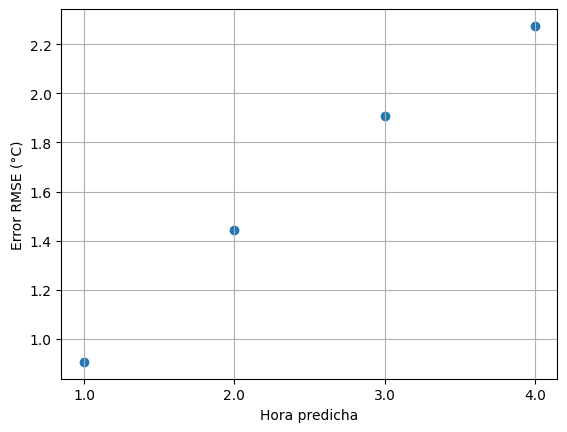

In [13]:
# 1. Generar las predicciones sobre el set de prueba
y_ts_pred_s = modelo.predict(x_ts_s, verbose=0)

# 2. Realizar la transformación inversa de las predicciones para llevar sus
# valores a la escala original
y_ts_pred = scaler.inverse_transform(y_ts_pred_s)

# 3. Calcular RMSE para cada instante de tiempo predicho
diff_cuad = np.square(y_ts.squeeze()-y_ts_pred) # 4995x4
proms = np.mean(diff_cuad, axis=0) # 1x4
rmse = np.sqrt(proms) # 1x4

# Graficar rmse para cada timestep
t = np.linspace(1,4,4)

fig, ax = plt.subplots()
ax.scatter(t,rmse)
ax.set_xlabel('Hora predicha')
ax.set_ylabel('Error RMSE (°C)')
plt.xticks(ticks=t, labels=t)
plt.grid();

In [18]:
# Calcular los errores brutos (valores reales - valores predichos)
# y_ts.squeeze() tiene forma (4995, 4)
y_ts_real_flattened = y_ts.squeeze()

# y_ts_pred tiene forma (4995, 4) si viene de model.predict(x_ts_s)
# Sin embargo, en el paso anterior se aplanó a (19980,) en la variable y_ts_pred.
# Necesitamos remodelar y_ts_pred para que sea (4995, 4) para compararlo con y_ts_real_flattened

# La variable y_ts_pred_s (escalada) es la que se obtiene directamente de model.predict, y tiene la forma correcta.
# Vamos a re-generar y_ts_pred a partir de y_ts_pred_s para asegurar la forma (4995, 4).
y_ts_pred_reshaped = scaler.inverse_transform(y_ts_pred_s)

raw_errors = y_ts_real_flattened - y_ts_pred_reshaped

print(f"Shape de los errores brutos: {raw_errors.shape}")

Shape de los errores brutos: (4995, 4)


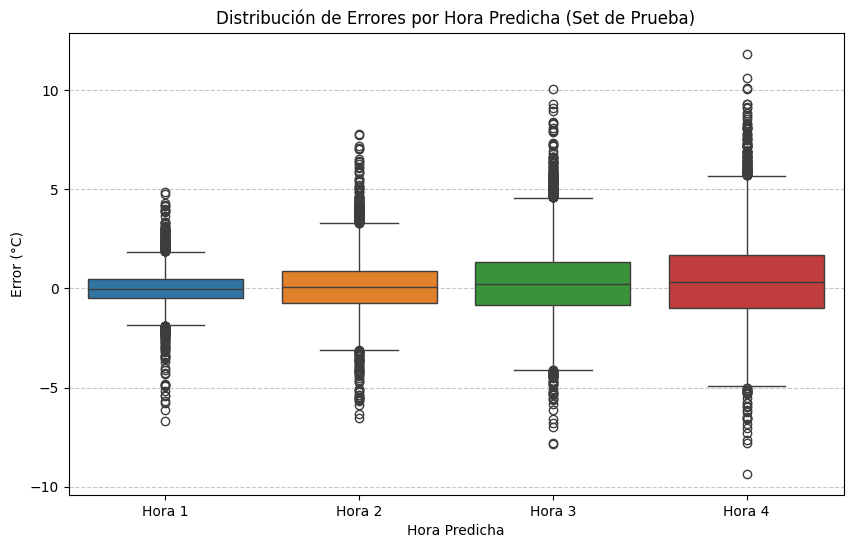

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convertir los errores a un DataFrame para facilitar el uso con seaborn
errors_df = pd.DataFrame(raw_errors, columns=[f'Hora {i+1}' for i in range(raw_errors.shape[1])])

plt.figure(figsize=(10, 6))
sns.boxplot(data=errors_df)
plt.title('Distribución de Errores por Hora Predicha (Set de Prueba)')
plt.xlabel('Hora Predicha')
plt.ylabel('Error (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

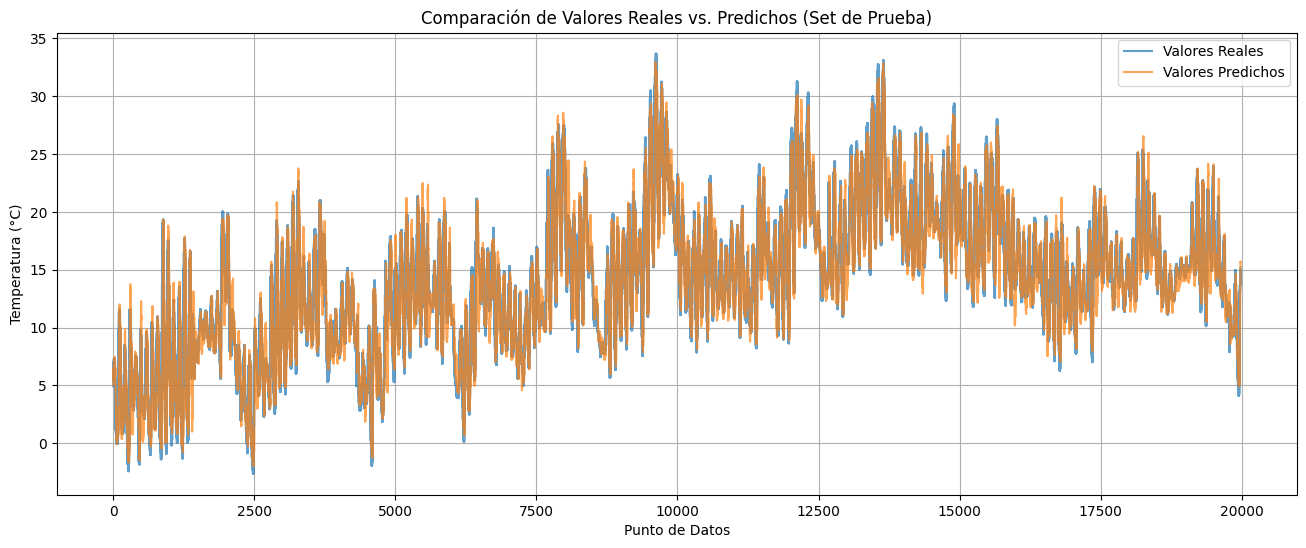

In [17]:
import matplotlib.pyplot as plt

# Obtener los valores reales y predichos
y_real = y_ts.flatten() # Aplanar el array y_ts para que coincida con y_ts_pred
y_pred = y_ts_pred

# Crear un índice para el eje x
index = np.arange(len(y_real))

# Crear el gráfico
plt.figure(figsize=(16, 6))
plt.plot(index, y_real, label='Valores Reales', alpha=0.7)
plt.plot(index, y_pred, label='Valores Predichos', alpha=0.7)
plt.title('Comparación de Valores Reales vs. Predichos (Set de Prueba)')
plt.xlabel('Punto de Datos')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.show()

Vemos que el RMSE se incrementa a medida que pasan las horas predichas, pasando de un error de 0.5 °C para la primera hora a un error de un poco más de 2.2 °C para la cuarta hora.

Esto nos permite plantear algunas hipótesis:

- Probablemente un incremento en el número de horas predichas generará un incremento en el RMSE
- Se podría reducir el RMSE al afinar el modelo
- Se podría mejorar el desempeño usando un modelo multivariado - multistep

##8. Predicciones con el modelo entrenado

Suponiendo que el modelo ya ha sido afinado, podemos ponerlo a prueba con el set *test*.

Usaremos la misma función `predecir` implementada en el video anterior:

In [14]:
def predecir(x, model, scaler):
    '''Genera la predicción de OUTPUT_LENGTH instantes
    de tiempo a futuro con el modelo entrenado.

    Entrada:
    - x: batch (o batches) de datos para ingresar al modelo
      (tamaño: BATCHES X INPUT_LENGTH X FEATURES)
    - model: Red LSTM entrenada
    - scaler: escalador (requerido para llevar la predicción a la escala original)

    Salida:
    - y_pred: la predicción en la escala original (tamaño: BATCHES X OUTPUT_LENGTH X FEATURES)
    '''

    # Calcular predicción escalada en el rango de -1 a 1
    y_pred_s = model.predict(x,verbose=0)

    # Llevar la predicción a la escala original
    y_pred = scaler.inverse_transform(y_pred_s)

    return y_pred.flatten()

In [15]:
# Calcular predicciones sobre el set de prueba
y_ts_pred = predecir(x_ts_s, modelo, scaler)

Analicemos este desempeño gráficamente mostrando las temperaturas originales y las predichas por el modelo para cada uno de los datos en el set de prueba:

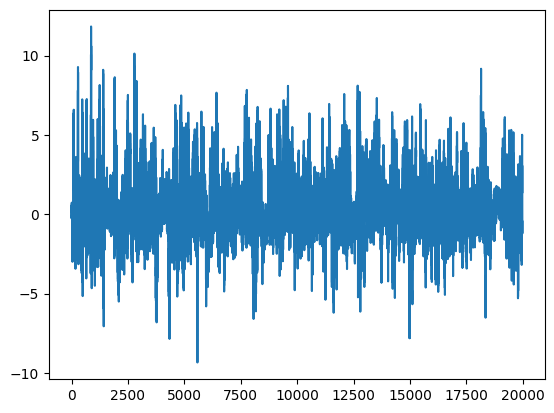

In [20]:
N = len(y_ts_pred)    # Número de predicciones
ndato = np.linspace(1,N,N)

# Cálculo de errores simples
errores = y_ts.flatten()-y_ts_pred
plt.plot(errores);

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50224 entries, 0 to 50223
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         50224 non-null  object 
 1   p (mbar)         50224 non-null  float64
 2   T (degC)         50224 non-null  float64
 3   Tpot (K)         50224 non-null  float64
 4   Tdew (degC)      50224 non-null  float64
 5   rh (%)           50224 non-null  float64
 6   VPmax (mbar)     50224 non-null  float64
 7   VPact (mbar)     50224 non-null  float64
 8   VPdef (mbar)     50224 non-null  float64
 9   sh (g/kg)        50224 non-null  float64
 10  H2OC (mmol/mol)  50224 non-null  float64
 11  rho (g/m**3)     50224 non-null  float64
 12  wv (m/s)         50224 non-null  float64
 13  max. wv (m/s)    50224 non-null  float64
 14  wd (deg)         50224 non-null  float64
dtypes: float64(14), object(1)
memory usage: 5.7+ MB


In [22]:
display(df.head())

,datetime,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
1,2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2,2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
3,2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
4,2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


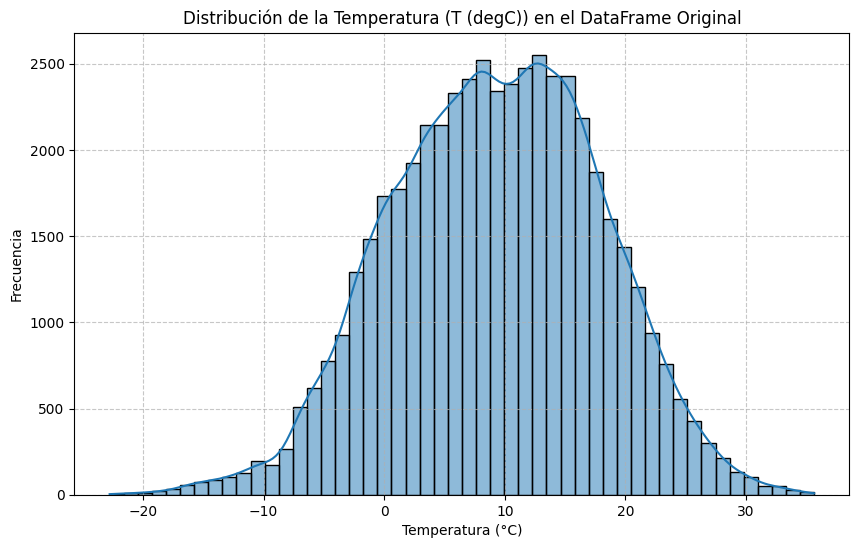

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['T (degC)'], kde=True, bins=50)
plt.title('Distribución de la Temperatura (T (degC)) en el DataFrame Original')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Se observa que:

- El promedio de errores es cercano a cero
- Pero en algunos instantes de tiempo se alcanzan errores extremos de hasta -10 y +10 grados.

Estos errores se podrían reducir al hacer una afinación del modelo o modificando el enfoque de predicción.

## 9. Conclusiones y sugerencias

- Hemos entrenado un segundo modelo univariado + multi-step
- Lo único que cambia en la implementación con respecto al modelo univariado + uni-step es la creación del set de datos supervisado y la creación de la Red LSTM.
- Se observa que el RMSE se incrementa a medida que aumentan las horas predichas, y que en generar los niveles de error para predicciones individuales aumentan con relación al modelo univariado + uni-step.
- El desempeño podría mejorar si se usa un enfoque de predicción diferente (por ejemplo multivariado + multi-step) o si se afina el modelo.

En el próximo video comenzaremos a enfocarnos en el desarrollo de modelos que aceptarán como entrada múltiples variables. Así que específicamente veremos cómo realizar predicciones usando el enfoque multivariado + uni-step.